In [ ]:
#Task 1:: Data Preparation:

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

# View first rows
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
# Dataset shape
print(df.shape)

# Column information
print(df.info())

# Summary statistics
print(df.describe())

# Check missing values
print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
# Convert TotalCharges to numeric if needed
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
X = df.drop('Churn', axis=1)   # Features
y = df['Churn']                # Target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5634, 20)
Testing set size: (1409, 20)


In [11]:
#Saiket_T2:: Exploratory Data Analysis (EDA):

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


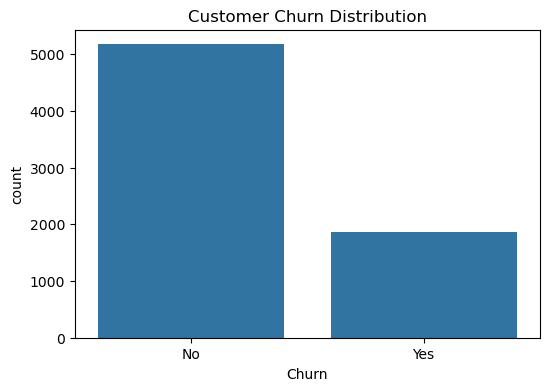

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

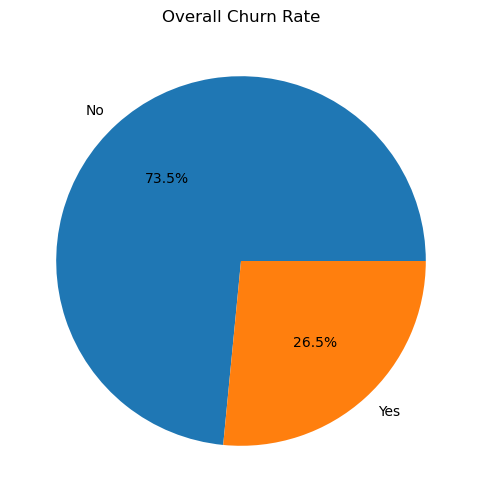

In [16]:
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    title="Overall Churn Rate"
)
plt.ylabel("")
plt.show()

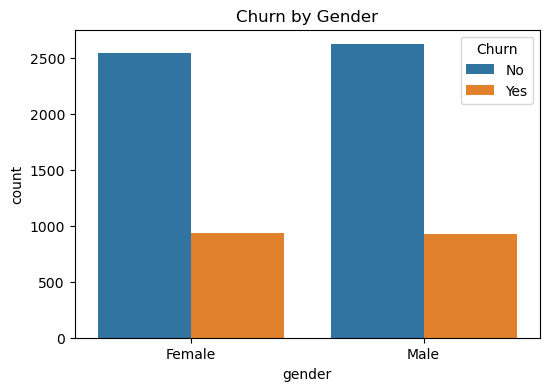

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Churn by Gender")
plt.show()

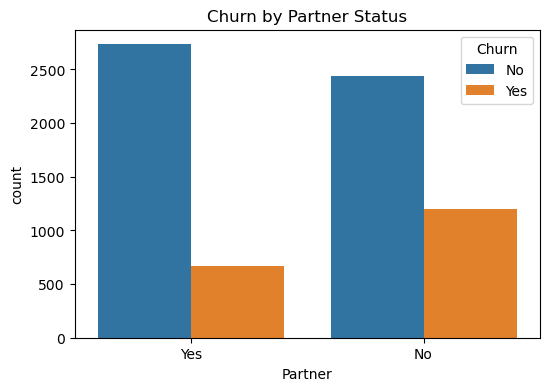

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title("Churn by Partner Status")
plt.show()

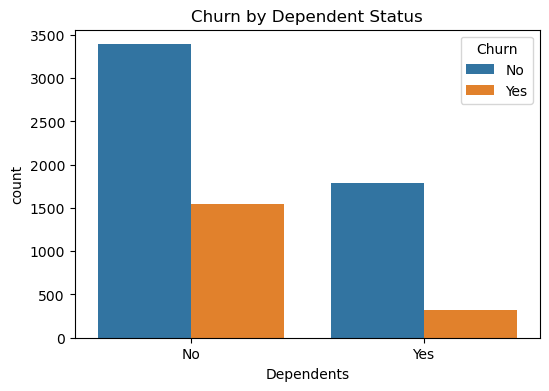

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title("Churn by Dependent Status")
plt.show()

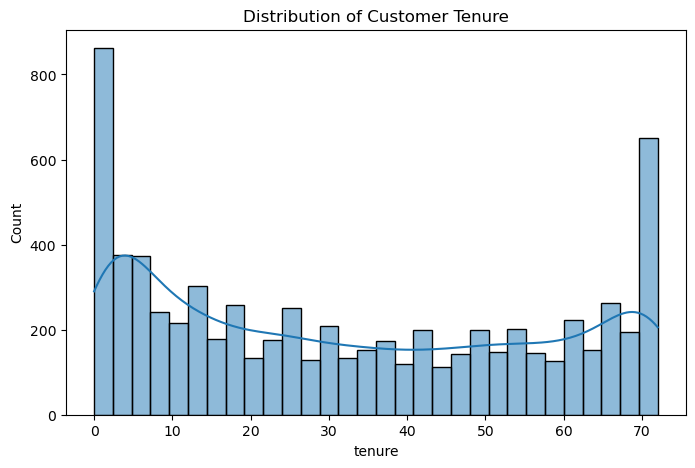

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Distribution of Customer Tenure")
plt.show()

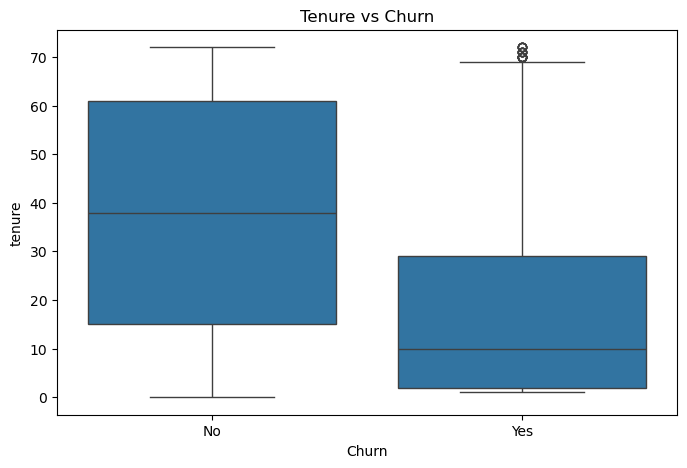

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

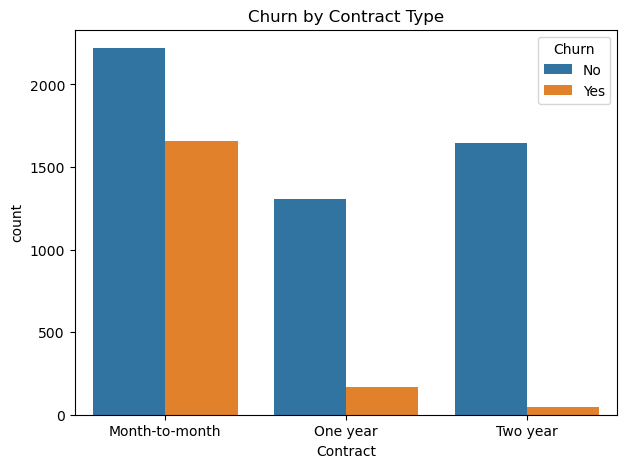

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

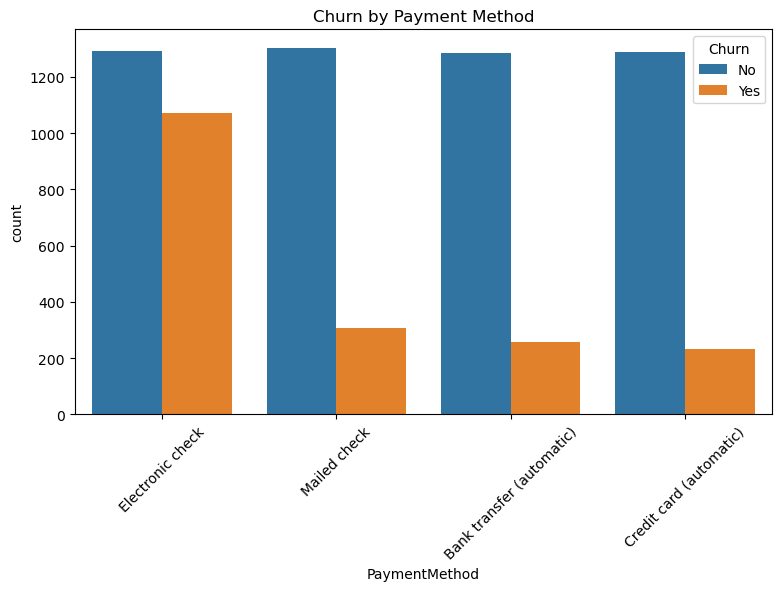

In [23]:
plt.figure(figsize=(9,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

In [24]:
#Task 3:: Customer Segmentation:

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [27]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1 Year','1-2 Years','2-4 Years','4-6 Years']
)

In [28]:
df['Charge_Group'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0,35,70,100,120],
    labels=['Low','Medium','High','Very High']
)

In [29]:
tenure_churn = pd.crosstab(df['Tenure_Group'], df['Churn'], normalize='index')
print(tenure_churn)

Churn               No       Yes
Tenure_Group                    
0-1 Year      0.523218  0.476782
1-2 Years     0.712891  0.287109
2-4 Years     0.796110  0.203890
4-6 Years     0.904868  0.095132


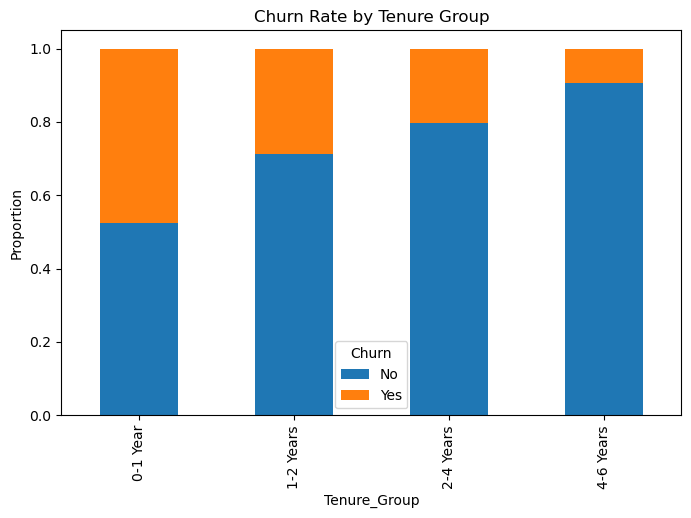

In [30]:
tenure_churn.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Proportion")
plt.show()

In [31]:
charge_churn = pd.crosstab(df['Charge_Group'], df['Churn'], normalize='index')
print(charge_churn)

Churn               No       Yes
Charge_Group                    
Low           0.891066  0.108934
Medium        0.760580  0.239420
High          0.621783  0.378217
Very High     0.719512  0.280488


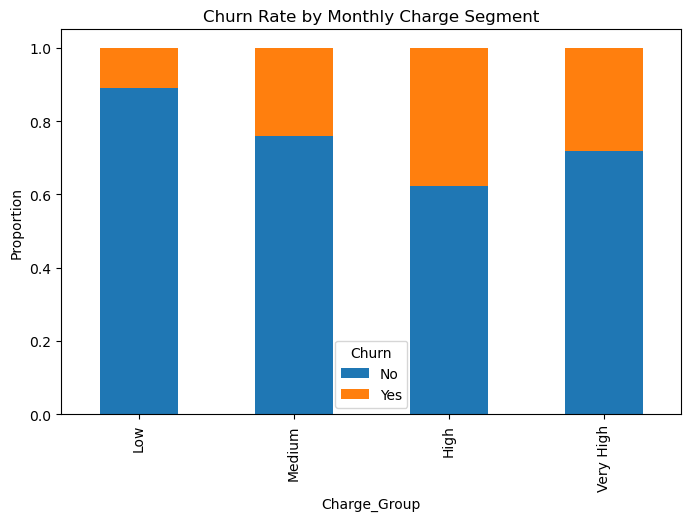

In [32]:
charge_churn.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn Rate by Monthly Charge Segment")
plt.ylabel("Proportion")
plt.show()

In [33]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
print(contract_churn)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


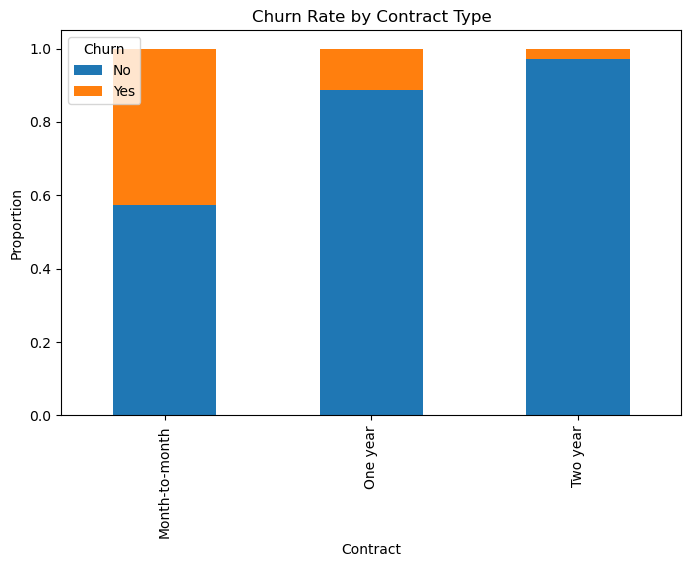

In [34]:
contract_churn.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

In [35]:
high_value_risk = df[
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['tenure'] > df['tenure'].median()) &
    (df['Churn'] == 'Yes')
]

print(high_value_risk[['tenure','MonthlyCharges','Contract','Churn']].head())

     tenure  MonthlyCharges        Contract Churn
13       49          103.70  Month-to-month   Yes
26       47           99.35  Month-to-month   Yes
38       34          106.35  Month-to-month   Yes
104      68          110.00        Two year   Yes
110      55           96.75  Month-to-month   Yes


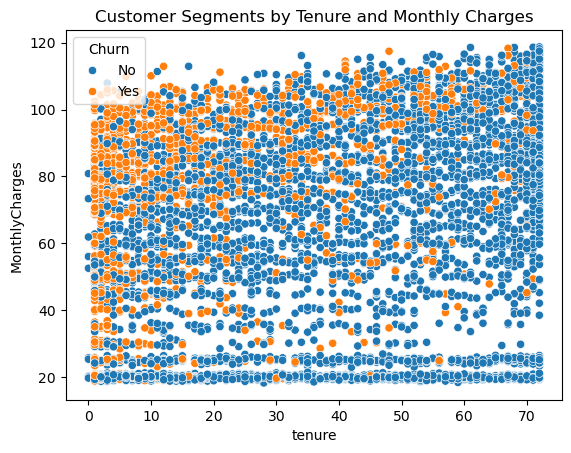

In [36]:
sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)

plt.title("Customer Segments by Tenure and Monthly Charges")
plt.show()

In [37]:
#Task 4:: Churn Prediction Model:

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [39]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [40]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [41]:
df = df.fillna(df.median())

In [42]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [46]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [47]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [48]:
def evaluate(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [49]:
print("Logistic Regression")
evaluate(y_test, log_pred)

print("Decision Tree")
evaluate(y_test, tree_pred)

print("Random Forest")
evaluate(y_test, rf_pred)

Logistic Regression
Accuracy: 0.8147622427253371
Precision: 0.6842105263157895
Recall: 0.5576407506702413
F1 Score: 0.6144756277695717
Decision Tree
Accuracy: 0.7196593328601846
Precision: 0.4696132596685083
Recall: 0.45576407506702415
F1 Score: 0.46258503401360546
Random Forest
Accuracy: 0.8019872249822569
Precision: 0.6690647482014388
Recall: 0.49865951742627346
F1 Score: 0.5714285714285714


In [50]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.67      0.50      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [51]:
importances = rf_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

tenure             0.160834
MonthlyCharges     0.143443
TotalCharges       0.134538
customerID         0.130394
Contract           0.083824
PaymentMethod      0.043388
OnlineSecurity     0.038036
TechSupport        0.037872
OnlineBackup       0.025411
InternetService    0.023977
dtype: float64

In [52]:
top_features = feature_importance.sort_values(ascending=False).head(10).index
X_selected = df[top_features]

In [53]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [5,10,20],
    'min_samples_split': [2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [54]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

evaluate(y_test, best_pred)

Accuracy: 0.8069552874378992
Precision: 0.6784452296819788
Recall: 0.514745308310992
F1 Score: 0.5853658536585366


In [55]:
#Task_5 :

In [56]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on test data
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8069552874378992
Precision: 0.6784452296819788
Recall: 0.514745308310992
F1 Score: 0.5853658536585366


In [57]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

tenure             0.170283
Contract           0.140910
MonthlyCharges     0.122479
TotalCharges       0.103191
customerID         0.086214
OnlineSecurity     0.070459
TechSupport        0.053474
PaymentMethod      0.039691
InternetService    0.034108
OnlineBackup       0.033150
dtype: float64


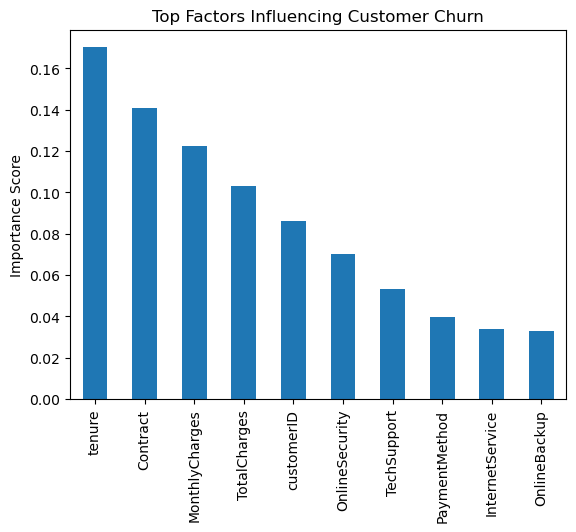

In [58]:
feature_importance.head(10).plot(kind='bar')

plt.title("Top Factors Influencing Customer Churn")
plt.ylabel("Importance Score")
plt.show()

In [59]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

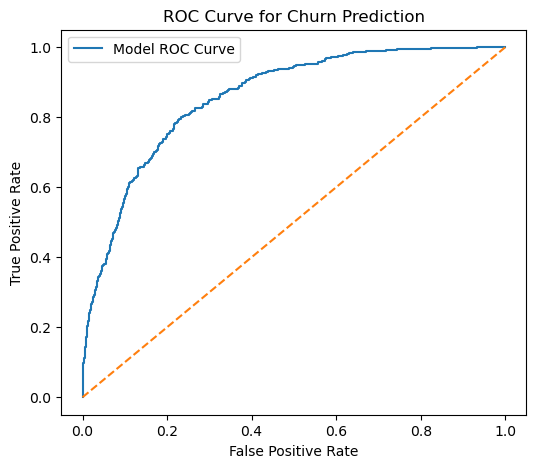

In [60]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Model ROC Curve")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Churn Prediction")

plt.legend()
plt.show()

In [61]:
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8575594936184748


In [62]:
#Task 6: Business Recommendation:

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Handle missing values
df = df.dropna()

# Convert target variable
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df.drop("customerID", axis=1), drop_first=True)

print(df_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



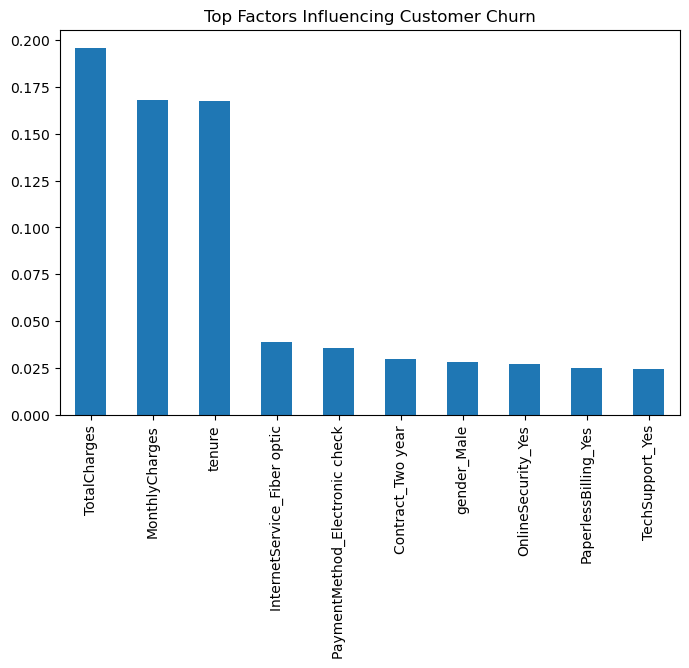

TotalCharges                      0.195802
MonthlyCharges                    0.168231
tenure                            0.167302
InternetService_Fiber optic       0.038661
PaymentMethod_Electronic check    0.035773
Contract_Two year                 0.029693
gender_Male                       0.027900
OnlineSecurity_Yes                0.027197
PaperlessBilling_Yes              0.024655
TechSupport_Yes                   0.024462
dtype: float64


In [3]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind="bar")
plt.title("Top Factors Influencing Customer Churn")
plt.show()

print(top_features)

In [4]:
df["Churn_Risk"] = model.predict_proba(X)[:,1]

# Customers with high churn risk
high_risk = df[df["Churn_Risk"] > 0.7]

print("High Risk Customers:", len(high_risk))

High Risk Customers: 1381


In [5]:
monthly_revenue = df["MonthlyCharges"].mean()

potential_customers = df[df["Contract"] == "Month-to-month"]

estimated_conversion = len(potential_customers) * 0.20

revenue_gain = estimated_conversion * monthly_revenue * 12

print("Estimated annual revenue gain:", revenue_gain)

Estimated annual revenue gain: 602623.3361774744


In [6]:
high_bill = df[df["MonthlyCharges"] > 80]

saved_customers = len(high_bill) * 0.25

revenue_saved = saved_customers * df["MonthlyCharges"].mean() * 12

print("Revenue retained:", revenue_saved)

Revenue retained: 518061.6744880546


In [7]:
new_customers = df[df["tenure"] < 12]

print("New customers:", len(new_customers))

New customers: 2058


In [8]:
current_churn_rate = df["Churn"].mean()

expected_reduction = 0.07  # 7% improvement

new_churn_rate = current_churn_rate - expected_reduction

total_customers = len(df)

customers_saved = total_customers * expected_reduction

avg_revenue = df["MonthlyCharges"].mean() * 12

annual_revenue_saved = customers_saved * avg_revenue

print("Current churn rate:", current_churn_rate)
print("New churn rate:", new_churn_rate)
print("Customers retained:", customers_saved)
print("Annual revenue saved:", annual_revenue_saved)

Current churn rate: 0.26578498293515357
New churn rate: 0.19578498293515356
Customers retained: 492.24000000000007
Annual revenue saved: 382755.24000000005
